# **Trading Strategy Backtest**

imports

In [1]:
# set notebook path too root
import sys
import os 
root = '/Users/amjadsaidam/Desktop/Quant stuff /FTMO/Trading Strategy One '
root_path = os.path.abspath(root)
target_folders = ['code', 'data_loaders']
target_paths = [os.path.join(root_path, dest) for dest in target_folders]
for p in ([root] + target_paths):
    if p not in sys.path:
        sys.path.insert(0, p)

# genral 
import pandas as pd
import numpy as np
import databento as db 
#from datetime import *
# ml 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# eda
import matplotlib.pyplot as plt
import seaborn as sys
# quant research analysis
import warnings
import quantstats as qs
# .py 
import backtest_engine as backtest
import trading_strategies as ts
import challenge_validation as cv
from optimisation import grid_search_params, run_grid_search, grid_search_statistics
from regime_filter import r2, categorise_regime
from walk_forward_analysis import walk_forward_analysis as wfa
from risk_management import RandomForestVol

## **Data**

In [2]:
# --- LOAD FOREX ---
data_asset_1_path = '/Users/amjadsaidam/Desktop/Quant stuff /FTMO/Trading Strategy One /data/CGBPUSD_OHLCV_1m_2021-07-17_2025-09-24.csv'
data_1 = pd.read_csv(data_asset_1_path, index_col = 'datetime', parse_dates = ['datetime'])
data_1 = ts.lower_to_higher_timeframe(data_1, '1min', '5min')

# MULTITIMEFRAME DATA
# get lower time frame data
h1_data = ts.lower_to_higher_timeframe(data_1, '5min', '1h')
h4_data = ts.lower_to_higher_timeframe(data_1, '5min', '4h')
h8_data = ts.lower_to_higher_timeframe(data_1, '5min', '8h')

# allign and merge higher resolution data to lower time frame 
multi_timeframe_data = ts.concatenate_timeframe_data(data_1, [h1_data, h4_data, h8_data]).dropna()

# add NY and LDN sesssion state columns
multi_timeframe_data = ts.add_session_flags(multi_timeframe_data) # copy to avoid editing original dataframe

# --- LOAD EQUITY ---
data_asset_2_path = '/Users/amjadsaidam/Desktop/Quant stuff /FTMO/Trading Strategy One /data/KO_OHLCV-1m.dbn'
data_2 = db.DBNStore.from_file(data_asset_2_path).to_df().drop(labels = ['symbol', 'rtype', 'publisher_id', 'instrument_id'], axis = 1) # by default has datetime index

# --- LOAD CRYPTO ---
data_asset_3_path = '/Users/amjadsaidam/Desktop/Quant stuff /FTMO/Trading Strategy One /data/BTCUSDT_5m_2017-09-01_to_2025-09-23.csv'
data_3 = pd.read_csv(data_asset_3_path, index_col = 'datetime', parse_dates = ['datetime'])

# --- EQUITY DATA JOIN ---
data_2 = ts.standerdise_join_data(data_1, data_2, '1min')

# --- CRYPTO DATA JOIN ---
data_3 = ts.standerdise_join_data(data_1, data_3)

# --- RE-ALIGN DATA ---
common_index = multi_timeframe_data.index
for df in [data_2, data_3]:
    common_index = common_index.intersection(df.index)

multi_timeframe_data = multi_timeframe_data.loc[common_index]
data_2 = data_2.loc[common_index]
data_3 = data_3.loc[common_index]

# check NaN values 
# len(data1_data2['high5min'][data1_data2.high5min.isna()])
# len(data1_data3['high5min'][data1_data2.high5min.isna()])

## **In-sample Combined Backtest**

In [3]:
backtest_payloads = {}
data = [multi_timeframe_data, data_2, data_3] # forex pair, equity, crypto
strategies = [ts.session_breakout, ts.vwap_breakout, ts.bollinger_band_cdv]

acc_risked = 0.01
acc_balance = 1e4
acc_balance_per_strat = 1 / len(data)

for i in range(len(data)): 
    backtest_payloads[f'strat{i+1}'] = backtest.backtest_strategy(
        data[i], 
        strategies[i], 
        account_balance = acc_balance_per_strat, 
    )

### **EDA**

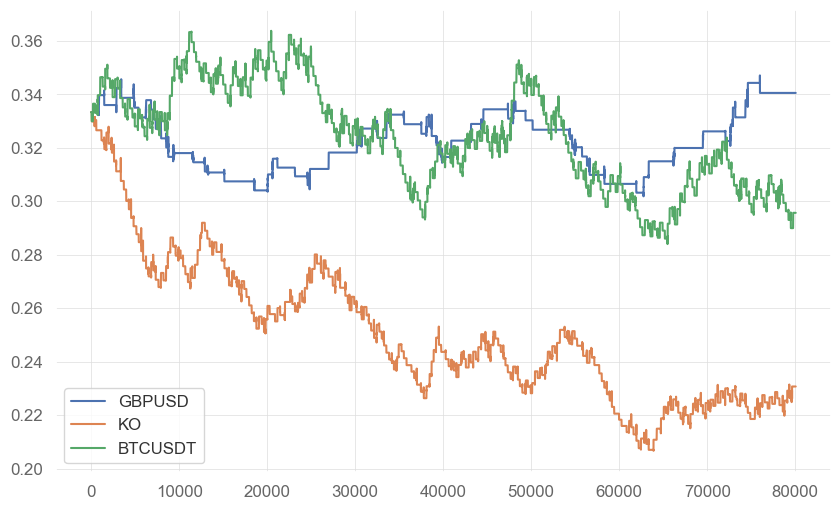

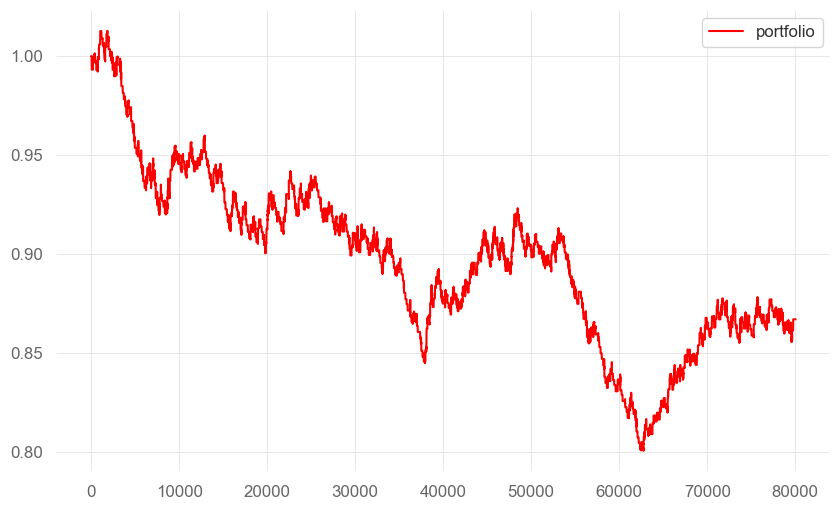

In [4]:
df_strat_1 = backtest_payloads['strat1']['data']
df_strat_2 = backtest_payloads['strat2']['data']
df_strat_3 = backtest_payloads['strat3']['data']

final_equity = df_strat_1.equity.values + df_strat_2.equity.values + df_strat_3.equity.values

plt.plot(df_strat_1.equity.values, linestyle = '-', label = 'GBPUSD')
plt.plot(df_strat_2.equity.values, linestyle = '-', label = 'KO')
plt.plot(df_strat_3.equity.values, linestyle = '-', label = 'BTCUSDT')
plt.legend()
plt.show()
plt.plot(final_equity, color = 'red', label = 'portfolio')
plt.legend()
plt.show()

## **Optimisation**

In [5]:
# # run grid search
# atr_multipliers = np.linspace(1.0, 10.0, 10)
# risk_rewards = np.linspace(1.0, 6.0, 10)

# gd_inputs = grid_search_params(multi_timeframe_data, 
#                                 ts.vwap_breakout, 
#                                 {'volume_window': 30},
#                                 atr_multipliers, 
#                                 risk_rewards)
# # gd_output = run_grid_search(gd_inputs)

In [6]:
# gd_summary_stats = grid_search_statistics(gd_output, risk_rewards, atr_multipliers)
# optimal_backtest = gd_summary_stats['opt_df']

In [7]:
# sys.heatmap(gd_summary_stats['ror'].to_numpy(), 
#              xticklabels = risk_rewards, 
#              yticklabels = atr_multipliers)
# plt.xlabel('Average True Range (ATR) Multiplier')
# plt.ylabel('Risk to Reward (R:R)')
# plt.show()

## **Challenge Validation**

In [8]:
# opt_close = optimal_backtest['close']
# opt_adj_returns = optimal_backtest['adjusted_returns']
# opt_equity = optimal_backtest['equity']

# chall_val = cv.PropFirmValidation(opt_adj_returns, 
#                                   opt_equity)
# chall_val.strategy_challenge_summary()

## **One Step Optimisation Results EDA**

In [9]:
# base_asset_returns = np.log(opt_close/opt_close.shift(1))
# backtest_returns = pd.DataFrame({'bench_rt': base_asset_returns, 'strat_rt': opt_adj_returns}, index = optimal_backtest.index)
# qs.reports.plots(returns = backtest_returns.strat_rt, benchmark = backtest_returns['bench_rt'], mode = 'full')

## **Walk Forward Analysis**

In [10]:
def run_wfa(data: pd.DataFrame, 
            forex: bool,
            acc_balance: float, 
            strat: backtest.SignalFunc, 
            strat_kwargs: dict = {},
            train_frac: float = 0.05, 
            eval_frac: float = 0.01, 
            commission_value: float = 0.00065):
    """
    """
    # results
    eval_adj_returns = np.array([])
    chall_passed = []
    ensemble_train_data_size = []
    ensemble_no_w_per_batch = []
    no_oos_w_trades_per_batch = []
    no_oos_trades_per_batch = []
    skipped_trades_per_batch = []
    oos_trade_rr = []
    
    y_actual, y_predict = np.array([]), np.array([])
    ensemble_predict_eval = {}

    # defaults vars
    wfa_partions = wfa(data, train_frac, eval_frac) # all train, eval sets of equal shape
    train_sets = wfa_partions['train_sets']
    eval_sets = wfa_partions['eval_sets']

    wfa_start_time = train_sets[0].index.min()
    oos_start_time = eval_sets[0].index.min()
    oos_end_time = eval_sets[-1].index.max()
    oos_elapsed_time = (oos_end_time - oos_start_time).days
    
    opt_atr = 2.0
    opt_rr = 2.0

    atr_multipliers = np.linspace(2.0, 5.0, 5)
    risk_rewards = np.linspace(3.0, 6.0, 5)

    equity = acc_balance

    for train_df, eval_df in zip(train_sets, eval_sets):
        # --- in sample / out of sample backtest ---
        gd_inputs = grid_search_params(data = train_df, 
                                       strat = strat,
                                       account_balance = acc_balance, 
                                       strat_kwargs = strat_kwargs,
                                       atr_multilpiers = atr_multipliers, 
                                       risk_rewards = risk_rewards)
        gd_output = run_grid_search(gd_inputs)
        gd_summary_stats = grid_search_statistics(gd_output, 
                                                  risk_rewards, 
                                                  atr_multipliers)

        opt_df = gd_summary_stats['opt_df']

        # --- instentiate ml model ---
        # features
        ml_features = opt_df.loc[:, ['atr_pct', 'regime', 'breakout_conv', 'rel_volume']] # strategy incoming data must have identical column names
        # train model to instentiate pipeline and save model to class method 
        ensemble = RandomForestVol(ml_features, opt_df['ml_label'], categorical_col = 'regime') 
        model_tr = ensemble.train_model(train_split = 1) # without evaluation logic, holdout is 0%, no eval data 

        # eval logic for train_split < 1 
        # CODE HERE
        
        # update optimal attributes 
        opt_atr = gd_summary_stats['opt_atr']
        opt_rr = gd_summary_stats['opt_rr']

        # run out of sample backtest 
        eval_backtest = backtest.backtest_strategy(data = eval_df, 
                                                   forex = forex,
                                                   signal_fc = strat, 
                                                   signal_kwargs = strat_kwargs, 
                                                   account_balance = equity, 
                                                   atr_multiplier = opt_atr, 
                                                   risk_reward = opt_rr, 
                                                   consecutive_loss_before_skip = 2, 
                                                   ensamble_signal_validation = ensemble.model, 
                                                   commission_pct = commission_value) # account for round trip fee 
        eval_df = eval_backtest['data']

        # --- logs ---
        # ml label logs 
        label = eval_df['ml_label'] # value per valid tarde
        pred = eval_df['ml_label_predict'] # value per trade 
        valid_mask = ~pd.isna(label) & ~pd.isna(pred) # mask to drop all predictions with no associted label 
        y_actual = np.append(y_actual, label[valid_mask]) 
        y_predict = np.append(y_predict, pred[valid_mask])

        # ml prediction logs 
        ensemble_train_data_size.append(ensemble.y.shape[0])
        ensemble_w_mask = np.isin(ensemble.y, 1)
        no_w_ensemble = ensemble.y[ensemble_w_mask].shape[0]
        ensemble_no_w_per_batch.append(no_w_ensemble)

        # trade metadata
        oos_trade_rr.append(sum(eval_df['trade_rr']))
        no_oos_trades_per_batch.append(eval_backtest['total_trades'])
        no_oos_w_trades_per_batch.append(eval_backtest['winning_trades'])
        skipped_trades_per_batch.append(eval_backtest['skipped_trades'])
        
        # prop firm challenge results 
        chall_val = cv.PropFirmValidation(eval_df['adjusted_returns'], eval_df['equity'])
        chall_val.best_day_ceiling = 0.5 # best day pnl % can not exceed 50%
        chall_res = chall_val.strategy_challenge_summary()

        # log results 
        eval_adj_returns = np.append(eval_adj_returns, eval_df['adjusted_returns'].to_numpy())
        chall_passed.append(
            all(chall_res.values())
        )

    # ml evaluation logs 
    if y_actual.size>=1 and y_predict.size>=1: # require atleast one set of valid true and prediction labels
        y_actual, y_predict = y_actual.astype(int), y_predict.astype(int)
        ensemble_predict_eval['accuracy'] = accuracy_score(y_actual, y_predict)
        ensemble_predict_eval['confusion_matrix'] = confusion_matrix(y_actual, y_predict)
        #ensemble_predict_eval['summary'] = classification_report(y_actual, y_predict) # given prediction of only one class, 1, recall is always zero (maximise model precision)

    # --- wfa summary ---
    wfa_summary = {}
    
    wfa_summary['eval_challenges_passed'] = np.round(sum(chall_passed)/len(chall_passed), 4)
    wfa_summary['backtest_duration_days'] = oos_elapsed_time
    wfa_summary['no_oos_batches'] = len(eval_sets)
    wfa_summary['no_oos_days_batch'] = (eval_sets[0].index.max() - oos_start_time).days
    wfa_summary['no_is_days_batch'] = (train_sets[0].index.max() - wfa_start_time).days
    wfa_summary['no_oos_5m_batch'] = len(eval_sets[0]) 
    wfa_summary['no_oos_trades'] = sum(no_oos_trades_per_batch)
    wfa_summary['prob_signal'] = wfa_summary['no_oos_trades'] / wfa_summary['backtest_duration_days']
    wfa_summary['win_percentage'] = sum(no_oos_w_trades_per_batch) / wfa_summary['no_oos_trades'] if wfa_summary['no_oos_trades'] > 0 else 0
    wfa_summary['avg_trade_rr'] = np.mean(oos_trade_rr, axis = -1)
    wfa_summary['required_win_rate_to_brake_even'] = wfa_summary['avg_trade_rr'] / (1 + wfa_summary['avg_trade_rr'])
    wfa_summary['avg_trades_per_batch'] = int(np.mean(no_oos_trades_per_batch, axis = -1))
    wfa_summary['avg_skipped_trades_per_batch'] = int(np.mean(skipped_trades_per_batch, axis = -1))
    wfa_summary['avg_ml_model_train_data_size'] = np.mean(ensemble_train_data_size, axis = -1)
    wfa_summary['avg_ensemble_train_class_balance'] = np.round(sum(ensemble_no_w_per_batch) / sum(ensemble_train_data_size), 4)

    return {
        'wfa_summary': wfa_summary, 
        'wfa_ensemble_model_validation': ensemble_predict_eval, 
        'eval_adjusted_returns': eval_adj_returns, 
    }

In [78]:
from datetime import datetime
end = datetime.today().date()
start = end - pd.Timedelta(value = 1, unit = 'D')

(end - start).days * 24 * 60

1 * 2 * 5 / 10 

1.0

In [11]:
# run multi-strategy wfa 
data = [multi_timeframe_data, data_2, data_3] # forex, equity, crypto
strats = [ts.session_breakout, ts.vwap_breakout, ts.bollinger_band_cdv]
strats_kwargs = [{}, {'volume_window': 1}, {}]
forex = [False, False, False]
commissions = [0.0, 0.00004, 0.00004] 

account_balance = 1e4
account_balance_per_strat = acc_balance / len(data)

wfa_payloads = {}
for i in range(len(data)):
    wfa_payloads[f'wfa_strat_{i}'] = run_wfa(data = data[i], 
                                             forex = forex[i],
                                             strat = strats[i], 
                                             acc_balance = account_balance_per_strat,
                                             strat_kwargs = strats_kwargs[i],
                                             train_frac = 0.05, 
                                             eval_frac = 0.02,
                                             commission_value = 0)
# outputs 
for payload in wfa_payloads.values():
    for k, v in payload['wfa_summary'].items():
        print(f'{k}: {v}')
    print('\n')

eval_challenges_passed: 0.0
backtest_duration_days: 382
no_oos_batches: 38
no_oos_days_batch: 7
no_is_days_batch: 20
no_oos_5m_batch: 1601
no_oos_trades: 23
prob_signal: 0.060209424083769635
win_percentage: 0.43478260869565216
avg_trade_rr: 0.10003168052918239
required_win_rate_to_brake_even: 0.09093527241057371
avg_trades_per_batch: 0
avg_skipped_trades_per_batch: 9
avg_ml_model_train_data_size: 3.3947368421052633
avg_ensemble_train_class_balance: 0.4264


eval_challenges_passed: 0.0
backtest_duration_days: 382
no_oos_batches: 38
no_oos_days_batch: 7
no_is_days_batch: 20
no_oos_5m_batch: 1601
no_oos_trades: 68
prob_signal: 0.17801047120418848
win_percentage: 0.36764705882352944
avg_trade_rr: 0.5053818997936219
required_win_rate_to_brake_even: 0.3357167373029439
avg_trades_per_batch: 1
avg_skipped_trades_per_batch: 17
avg_ml_model_train_data_size: 11.947368421052632
avg_ensemble_train_class_balance: 0.348


eval_challenges_passed: 0.0
backtest_duration_days: 382
no_oos_batches: 38
no_o

## **WFA EDA**

ensemble model validatiion

wfa_strat_0

-------------------------------------

0.45454545454545453


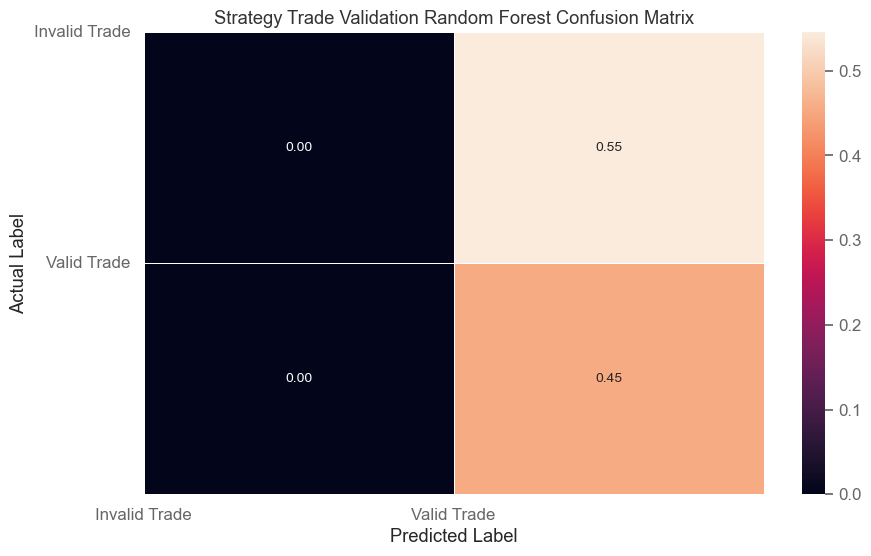

wfa_strat_1

-------------------------------------

0.35


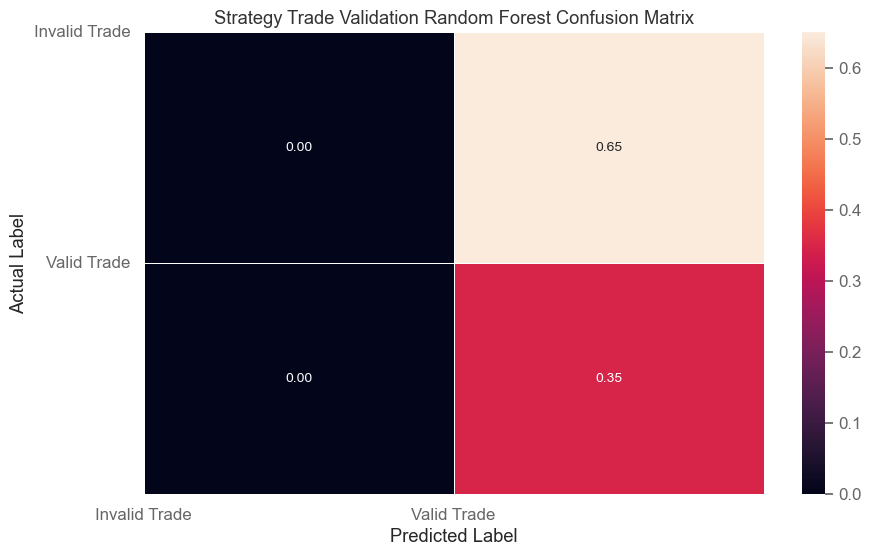

wfa_strat_2

-------------------------------------

0.2619047619047619


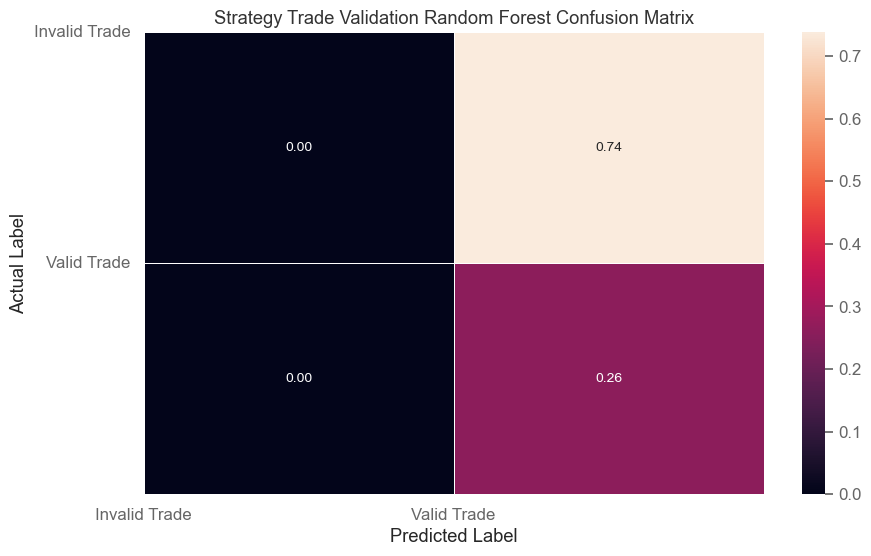

In [12]:
for k in wfa_payloads.keys():
    print(k)
    print('\n-------------------------------------\n')
    # model total wfa oos accuracy
    print(wfa_payloads[k]['wfa_ensemble_model_validation']['accuracy'])

    # model total wfa oos confusion matrix
    matrix = wfa_payloads[k]['wfa_ensemble_model_validation']['confusion_matrix']
    matrix = matrix.astype(float) / matrix.sum(axis = 0)[1]

    sys.heatmap(matrix, annot = True, annot_kws = {'size': 10}, fmt = '.2f', linewidth = 0.5)
    class_names = ['Invalid Trade', 'Valid Trade']
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation = 0.0)
    plt.yticks(tick_marks, class_names, rotation = 0.0)
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.title('Strategy Trade Validation Random Forest Confusion Matrix')
    plt.show()

    # model total wfa summary evaluation statistics 
    #print(wfa_payloads[k]['wfa_ensemble_model_validation']['summary'])

final performance

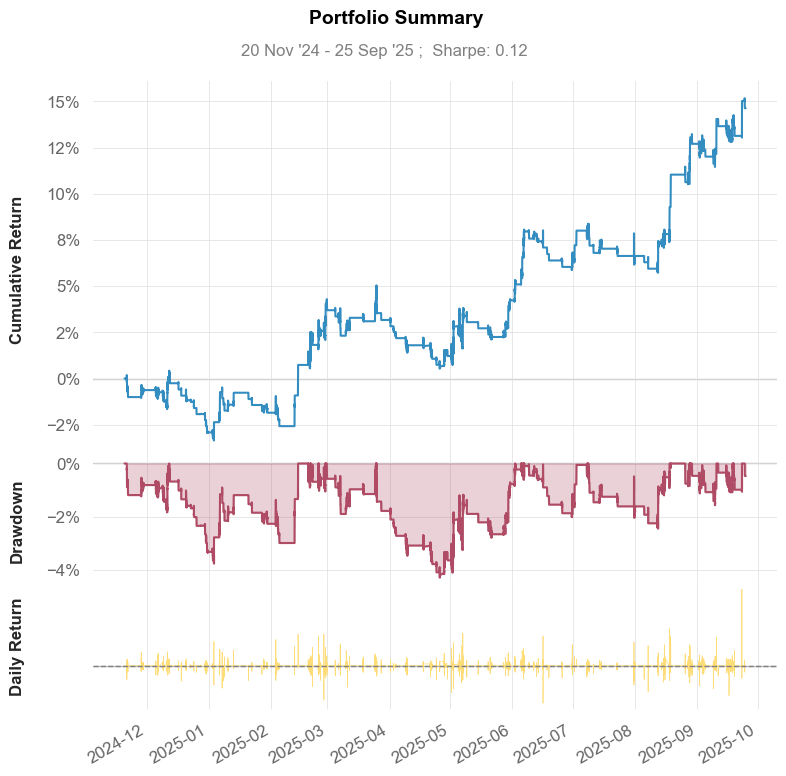

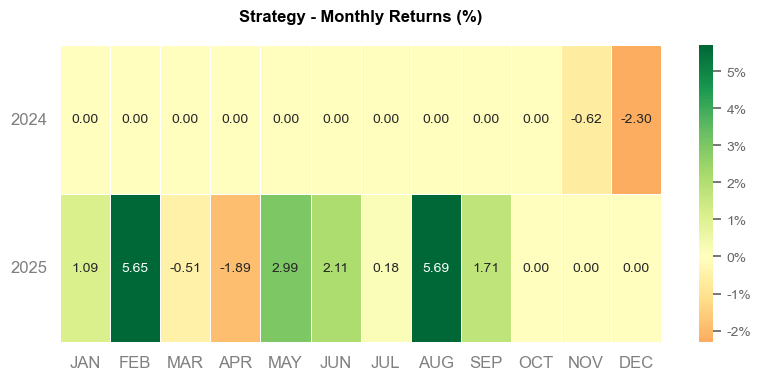

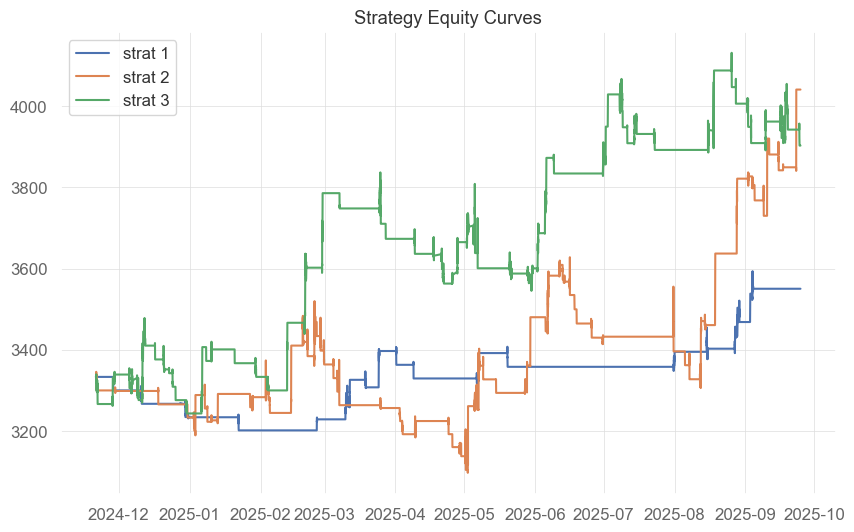

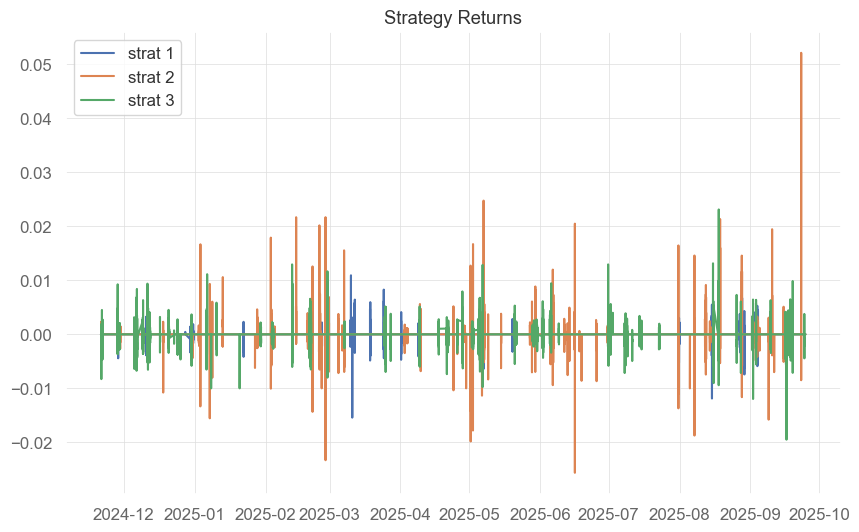

In [13]:
# run backtest analysis 
n = len(multi_timeframe_data)
m = len(wfa_payloads['wfa_strat_0']['eval_adjusted_returns'])
eval_index = multi_timeframe_data.index[n-m: ]

# calculate strategy portfolio equity 
equity = lambda acc_balance, returns: acc_balance * np.cumprod(1 + returns) # assuming captail allocation per strategy 

strat_1_rt = wfa_payloads['wfa_strat_0']['eval_adjusted_returns']
strat_2_rt = wfa_payloads['wfa_strat_1']['eval_adjusted_returns']
strat_3_rt = wfa_payloads['wfa_strat_2']['eval_adjusted_returns']

eq_strat_1 = equity(account_balance_per_strat, strat_1_rt)
eq_strat_2 = equity(account_balance_per_strat, strat_2_rt)
eq_strat_3 = equity(account_balance_per_strat, strat_3_rt)
eq_port = eq_strat_1 + eq_strat_2 + eq_strat_3

portfolio_equity_curve = pd.Series(eq_port, index = eval_index)
portfolio_adjusted_returns = np.log(portfolio_equity_curve / portfolio_equity_curve.shift(1)).fillna(0)

# print
base_asset_close = multi_timeframe_data['close']
base_asset_returns = np.log(base_asset_close/base_asset_close.shift(1))
backtest_returns = pd.DataFrame({
    'bench_rt': base_asset_returns[n-m: ], 
    'port_rt': portfolio_adjusted_returns,
    'strat_1': strat_1_rt, 
    'strat_2': strat_2_rt, 
    'strat_3': strat_3_rt
}, index = eval_index)

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category = DeprecationWarning, message=".*generic.* unit for NumPy timedelta.*")
    # strategy report 
    qs.reports.plots(returns = backtest_returns.port_rt, 
                     benchmark = backtest_returns['bench_rt'], 
                     mode = 'basic')
    # seperate strategy equity
    plt.title('Strategy Equity Curves')
    plt.plot(eval_index, eq_strat_1, label = 'strat 1')
    plt.plot(eval_index, eq_strat_2, label = 'strat 2')
    plt.plot(eval_index, eq_strat_3, label = 'strat 3')
    plt.legend()
    plt.show()
    # returns 
    plt.title('Strategy Returns')
    plt.plot(eval_index, strat_1_rt, label = 'strat 1')
    plt.plot(eval_index, strat_2_rt, label = 'strat 2')
    plt.plot(eval_index, strat_3_rt, label = 'strat 3')
    plt.legend()
    plt.show()

## **Risk Analysis**